**Final Project:  PART 2: Text Analysis of CFPB Consumer Complaint Dataset https://cfpb.github.io/api/ccdb/fields.html. using nltk methods. NOTE:(PART 1 of our final project link is separate and provided at the end IN THIS MARKDOWN, please click there to access the other ipynb file and the video link to that)**

**VIDEO LINK (PART2)** : https://youtu.be/zgPBgAysRsE


About the data : Citation Source : https://cfpb.github.io/api/ccdb/fields.html
"What is this data?
The Consumer Complaint Database is a collection of complaints about consumer financial products and services that we sent to companies for response. Complaints are published after the company responds, confirming a commercial relationship with the consumer, or after 15 days, whichever comes first. Complaints referred to other regulators, such as complaints about depository institutions with less than $10 billion in assets, are not published in the Consumer Complaint Database. The database generally updates daily. Learn more"

**Submitted by:** Group Members: Banu Boopalan, Umais Siddiqui, Shri Tripathi

**Date:** 5/15/2025

**Course:** Data Science – DATA620

**Final Project (SEPARATE LINK) : PART 1 (Analyzing the Evolution of Stock Market Correlations Using Network Visualization) is separate notebook and link to github here** : https://github.com/BanuB/CUNY-DATA-620-WebAnalytics/blob/main/Final%20Project%2005152025/FinalProject.ipynb

In [27]:
import pandas as pd

# Read the complaints.csv file into a DataFrame
file_path = r'C:\Users\Banu\Downloads\complaintsUS\complaints.csv'
# Read the entire file to determine dtypes
df_sample = pd.read_csv(file_path)
df_sample.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-05-02,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,27530,NaN,NaN,Web,2025-05-02,In progress,Yes,NaN,13272522
1,2025-05-02,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Experian Information Solutions Inc.,MA,02121,NaN,NaN,Web,2025-05-02,In progress,Yes,NaN,13272526
2,2025-05-02,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,NaN,NaN,Experian Information Solutions Inc.,TX,77583,NaN,NaN,Web,2025-05-02,In progress,Yes,NaN,13272557
3,2025-05-02,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,CT,06606,NaN,NaN,Web,2025-05-02,In progress,Yes,NaN,13272593
4,2025-05-02,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Experian Information Solutions Inc.,TX,79938,NaN,NaN,Web,2025-05-02,In progress,Yes,NaN,13272697


In [28]:
import nltk
from datetime import datetime
from collections import defaultdict

# Check if nltk punkt is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

start_time = datetime.now()
print("Available columns:")
print(df_sample.columns.tolist())
necessary_columns = ['Date received', 'Company', 'Sub-product', 'Consumer complaint narrative']
available_columns = df_sample.columns.tolist()
column_mapping = {}
for col in necessary_columns:
    matches = [c for c in available_columns if col.lower() in c.lower()]
    if matches:
        column_mapping[col] = matches[0]

print(f"Column mapping: {column_mapping}")


Available columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
Column mapping: {'Date received': 'Date received', 'Company': 'Company public response', 'Sub-product': 'Sub-product', 'Consumer complaint narrative': 'Consumer complaint narrative'}


**CREATE CORPUS FROM COMPLAINT NARATIVES**

First we create a corpus of the complaints narratives by Sub Product, Date and Company.
Since this is a large file, we have sampled about 500000 records 
Total rows: 16461928, sampling probability: 0.0304
Sampled 273305 rows from 90 chunks
24965 corpus documents were created
This corpus gives us a good amount of text to work with around Sub Product and complaint narratives that were submitted by consumers**


In [29]:
import pandas as pd
import nltk
from datetime import datetime
from collections import defaultdict
import gc  # For garbage collection
import random  # For sampling
import warnings  # For suppressing warnings

# Suppress warnings
warnings.filterwarnings('ignore')

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')


start_time = datetime.now()
sample_size = 500000  
# Count total rows to calculate sampling probability
total_rows = 0
with open(file_path, encoding='utf-8', errors='replace') as f:
    for _ in f:
        total_rows += 1
total_rows -= 1  # Subtract 1 for header row
sampling_prob = sample_size / total_rows
print(f"Total rows: {total_rows}, sampling probability: {sampling_prob:.4f}")
chunk_size = 100000  
reader = pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)  # Added low_memory=False to avoid dtype warnings

# Dictionary to collect narratives
corpus = defaultdict(list)

print("Processing data in chunks with sampling...")

chunk_count = 0
sampled_rows = 0
total_chunks = total_rows // chunk_size + 1

major_milestones = [1, int(total_chunks * 0.25), int(total_chunks * 0.5), int(total_chunks * 0.75), total_chunks]

for chunk in reader:
    chunk_count += 1
    
    if chunk_count in major_milestones:
        print(f"Progress: {chunk_count}/{total_chunks} chunks ({chunk_count/total_chunks*100:.1f}% complete)")
    
    chunk_sample = chunk.sample(frac=sampling_prob, random_state=42)
    sampled_rows += len(chunk_sample)
    
    # Convert date column and extract month
    chunk_sample['Date received'] = pd.to_datetime(chunk_sample['Date received'], errors='coerce')
    chunk_sample['Month'] = chunk_sample['Date received'].dt.strftime('%Y-%m')
    chunk_sample['Consumer complaint narrative'] = chunk_sample['Consumer complaint narrative'].fillna('')
    
    for _, row in chunk_sample.iterrows():
        sub_product = str(row['Sub-product'])
        month = str(row['Month'])
        company = str(row['Company'])
        narrative = row['Consumer complaint narrative']
        
        if narrative:  # Skip empty narratives
            key = f"{sub_product}_{month}_{company}"
            corpus[key].append(narrative)
    
    # Clear chunk from memory
    del chunk
    del chunk_sample
    gc.collect()

print(f"Sampled {sampled_rows} rows from {chunk_count} chunks")
print("Converting narratives to joined text...")
# Join the collected narratives
for key in corpus:
    corpus[key] = " ".join(corpus[key])
print("Creating corpus DataFrame...")
corpus_df = pd.DataFrame([
    {'Key': key, 
     'Sub-product': key.split('_')[0], 
     'Month': key.split('_')[1], 
     'Company': key.split('_')[2], 
     'Corpus': text}
    for key, text in corpus.items()
])

print(f"Created {len(corpus_df)} corpus documents")
print("\nSample corpus entries:")
print(corpus_df.head())
output_file = 'complaintcorpus_subproductdtcomp.csv'
corpus_df.to_csv(output_file, index=False)
print(f"\nCorpus saved to {output_file}")

# End timer
end_time = datetime.now()


Total rows: 16461928, sampling probability: 0.0304
Processing data in chunks with sampling...
Progress: 1/165 chunks (0.6% complete)
Progress: 41/165 chunks (24.8% complete)
Progress: 82/165 chunks (49.7% complete)
Sampled 273305 rows from 90 chunks
Converting narratives to joined text...
Creating corpus DataFrame...
Created 24965 corpus documents

Sample corpus entries:
                                                 Key  \
0  Credit reporting_2025-04_FAIR COLLECTIONS & OU...   
1          Loan_2025-04_TRUIST FINANCIAL CORPORATION   
2  Credit reporting_2024-12_Experian Information ...   
3             Credit reporting_2025-02_EQUIFAX, INC.   
4  General-purpose credit card or charge card_202...   

                                  Sub-product    Month  \
0                            Credit reporting  2025-04   
1                                        Loan  2025-04   
2                            Credit reporting  2024-12   
3                            Credit reporting  2025-02   

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import warnings

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
sns.set_palette("deep")
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

EDA: We can calculated sentiment using polarity scores.
Overall Sentiment of each Company by the Compliant narratives reported by Consumers.
The Vader Sentiment analyzer is used to calculate a column for sentiment. We can see that WEBSTER BANK has some poor sentiment related to the customer narratives. VOLKSWAGEN financial services or VW Credit, Inc have positive sentiment related to customer complaints.

In [31]:
# Load the corpus 
print("Loading corpus from CSV...")
corpus_df = pd.read_csv('complaintcorpus_subproductdtcomp.csv')
print(f"Loaded {len(corpus_df)} documents")
sia = SentimentIntensityAnalyzer()

print("Calculating sentiment scores...")
corpus_df['sentiment'] = corpus_df['Corpus'].apply(
    lambda x: sia.polarity_scores(str(x))['compound'] if isinstance(x, str) else 0
)

corpus_df['Month'] = pd.to_datetime(corpus_df['Month'])

# 1. Overall sentiment by company
print("\n--- ANALYSIS 1: Find Sentiment by Company ---")
company_sentiment = corpus_df.groupby('Company')['sentiment'].agg(['mean', 'count']).reset_index()
company_sentiment = company_sentiment.sort_values(by='mean')
company_sentiment = company_sentiment[company_sentiment['count'] >= 10]  # Only include companies with sufficient data

print("\nCompanies with most negative sentiment:")
print(company_sentiment.head(10).to_string(index=False))

print("\nCompanies with most positive sentiment:")
print(company_sentiment.tail(10).to_string(index=False))



Loading corpus from CSV...
Loaded 24965 documents
Calculating sentiment scores...

--- ANALYSIS 1: Find Sentiment by Company ---

Companies with most negative sentiment:
                                          Company      mean  count
                            Harris & Harris, Ltd. -0.729181     21
            Linebarger Goggan Blair & Sampson LLP -0.717710     10
                    Cedars Business Services, LLC -0.716662     13
               WEBSTER BANK, NATIONAL ASSOCIATION -0.612300     10
           The Receivable Management Services LLC -0.572512     17
                Professional Debt Mediation, Inc. -0.561833     24
                             ZWICKER & ASSOCIATES -0.559150     14
The Law Offices of Mitchell D. Bluhm & Associates -0.543429     14
                                    T.S. Holdings -0.522931     42
                            Conduent Incorporated -0.513164     22

Companies with most positive sentiment:
                          Company     mean  count
  

**Look at trends of customer sentiment over time**
Between 2016 and 2020, the complaint trends are more positive than negative in the market. 


--- ANALYSIS 2: Look at trends of sentiment over time ---


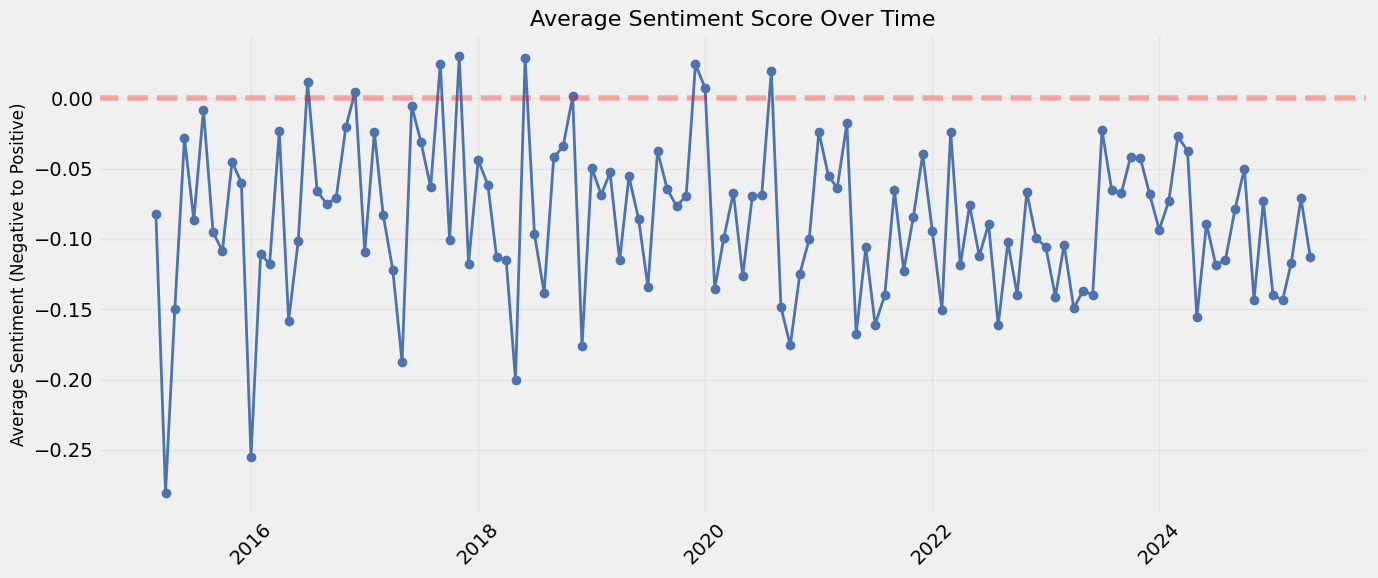

In [39]:

print("\n--- ANALYSIS 2: Look at trends of sentiment over time ---")
time_sentiment = corpus_df.groupby('Month')['sentiment'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(time_sentiment['Month'], time_sentiment['sentiment'], marker='o', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.title('Average Sentiment Score Over Time', fontsize=16)
plt.ylabel('Average Sentiment (Negative to Positive)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
# Display the plot in the notebook
plt.show()
plt.savefig('sentiment_over_time.png', dpi=300, bbox_inches='tight')
plt.close()

**What type of products have the worse compliants?**
** Government Benefit Cards had the most worst sentiment, the definition for these are**
"Instead of getting checks, recipients receive a type of prepaid card called a government benefit card. Each month the benefit amount is loaded onto the card. The federal government uses prepaid cards to pay certain federal benefits, such as veterans’ benefits or Social Security benefits."
CITE: [text](https://www.consumerfinance.gov/ask-cfpb/what-is-a-government-benefit-card-en-409/#:~:text=The%20federal%20government%20uses%20prepaid,one%20arranged%20through%20the%20government.)




--- ANALYSIS 3: GET SENTIMENT BY SUB-PRODUCT ---


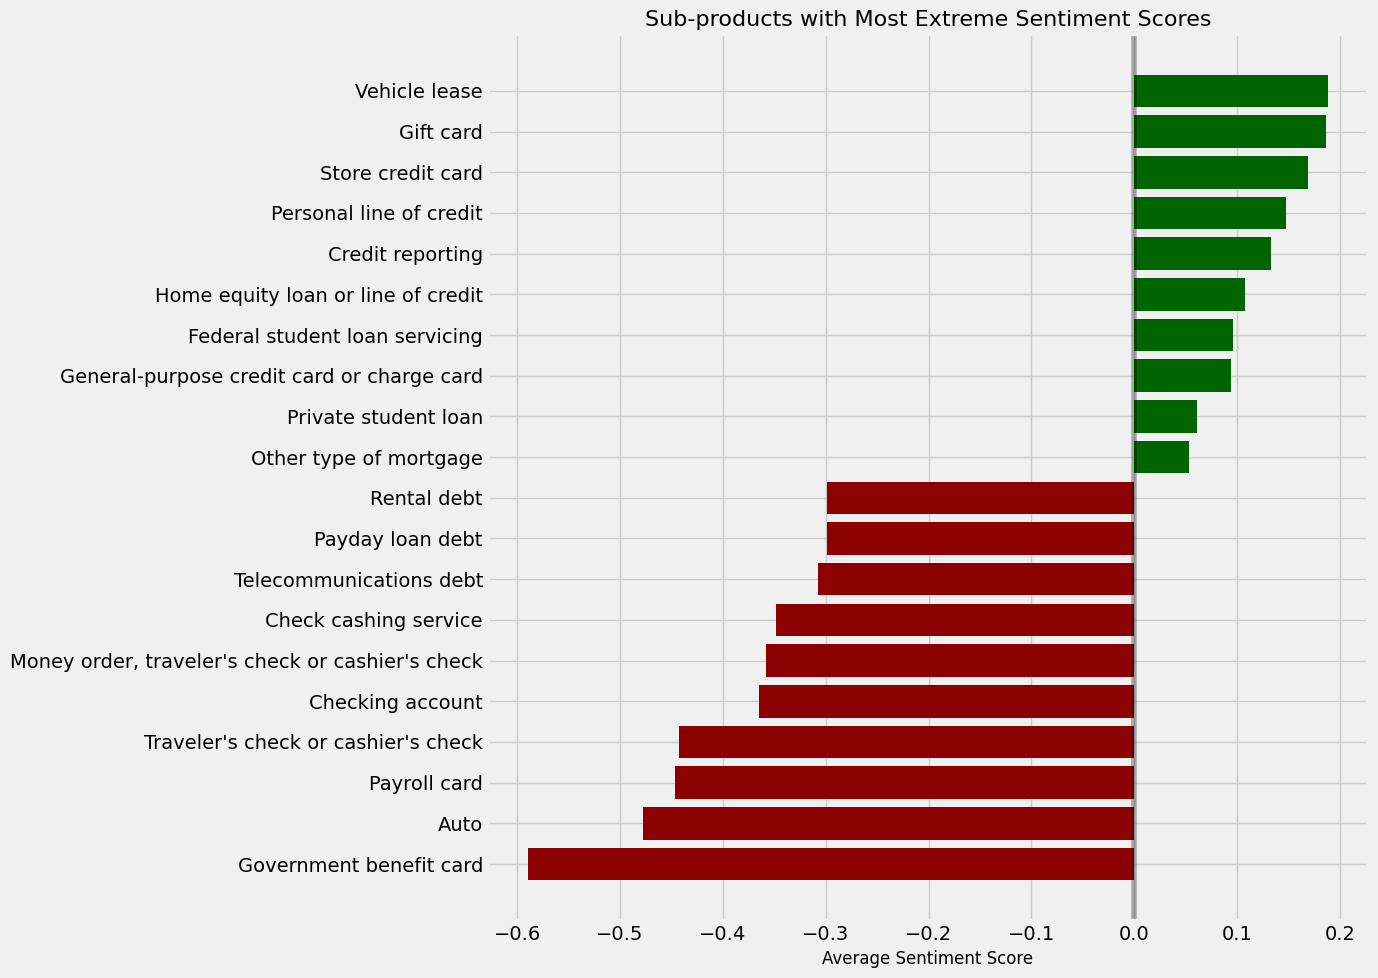

In [40]:

print("\n--- ANALYSIS 3: GET SENTIMENT BY SUB-PRODUCT ---")
subproduct_sentiment = corpus_df.groupby('Sub-product')['sentiment'].agg(['mean', 'count']).reset_index()
subproduct_sentiment = subproduct_sentiment[subproduct_sentiment['count'] >= 10]  # Filter for reasonable sample size
subproduct_sentiment = subproduct_sentiment.sort_values(by='mean')


# Plot for sub-products (top 10 most negative and positive)
plt.figure(figsize=(14, 10))
neg_subproducts = subproduct_sentiment.head(10).copy()
pos_subproducts = subproduct_sentiment.tail(10).copy()
combined_subprod = pd.concat([neg_subproducts, pos_subproducts])

plt.barh(combined_subprod['Sub-product'], combined_subprod['mean'], 
         color=['darkred' if s < 0 else 'darkgreen' for s in combined_subprod['mean']])
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Sub-products with Most Extreme Sentiment Scores', fontsize=16)
plt.xlabel('Average Sentiment Score', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('subproduct_sentiment.png', dpi=300, bbox_inches='tight')
plt.close()


Analysis of Capital One in the "Companies by Negative Impact Over Time" Graph
Looking at your attached visualization showing "Companies by Negative Impact Over Time" across 2023, 2024, and 2025:

HSBC seems to the on the worst sentiment on the year 2023. 
BOA, JPMC seem to have a higher volume of compliants but less severe than expected from HSBC that has lower volume but worse sentiment score.

INTERESTING FIND:

2023 (left panel): Capital One appears as "CAPITAL ONE FINANCIAL C" in the upper right quadrant with a moderately negative sentiment (around -0.3) and a relatively high complaint volume (approximately 75 complaints). But, the absence of Capital One in the 2024 and 2025 visualizations may show that they have made improvement in their customer sentiment or a reduction in complaint volume (this may have to be looked into to further prove the finding)


--- ANALYSIS 5: Plot Negative Sentiment over last 3 years---
Analyzing the most recent years in the dataset: [np.int32(2023), np.int32(2024), np.int32(2025)]


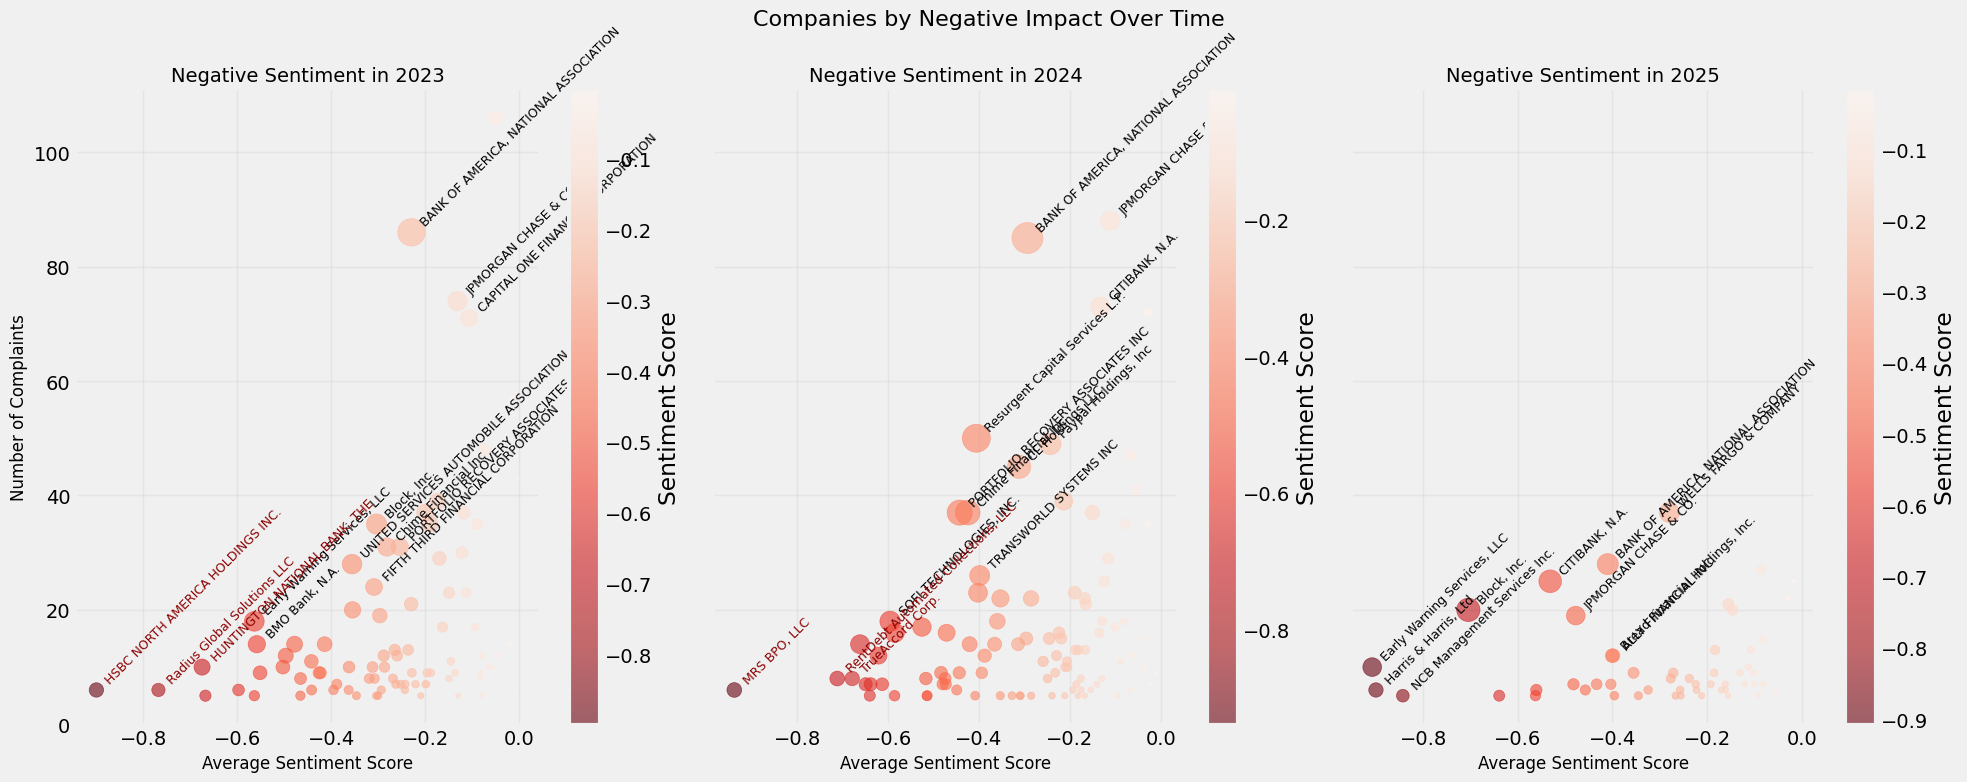

In [41]:

print("\n--- ANALYSIS 5: Plot Negative Sentiment over last 3 years---")
corpus_df['Year'] = corpus_df['Month'].dt.year
recent_years = sorted(corpus_df['Year'].unique())[-3:]
print(f"Analyzing the most recent years in the dataset: {recent_years}")
fig, axes = plt.subplots(1, len(recent_years), figsize=(20, 8), sharey=True)

for i, year in enumerate(recent_years):
    year_df = corpus_df[corpus_df['Year'] == year]
    
    year_sentiment = year_df.groupby('Company')['sentiment'].agg(['mean', 'count']).reset_index()
    year_sentiment = year_sentiment[year_sentiment['count'] >= 5]  
    year_sentiment = year_sentiment.sort_values(by='mean')
    negative_companies_year = year_sentiment[year_sentiment['mean'] < 0].copy()
    negative_companies_year['impact_score'] = negative_companies_year['count'] * abs(negative_companies_year['mean'])
    negative_companies_year = negative_companies_year.sort_values(by='impact_score', ascending=False)
    
    ax = axes[i]
    scatter = ax.scatter(
        negative_companies_year['mean'],
        negative_companies_year['count'],
        s=negative_companies_year['impact_score'] * 20,
        alpha=0.6,
        c=negative_companies_year['mean'],
        cmap='Reds_r'
    )

    for _, row in negative_companies_year.head(10).iterrows():
        ax.annotate(
            row['Company'],
            xy=(row['mean'], row['count']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            ha='left',
            rotation=45
        )
    
    most_negative = negative_companies_year.nsmallest(3, 'mean')
    for _, row in most_negative.iterrows():
        if row['Company'] not in negative_companies_year.head(10)['Company'].values:
            ax.annotate(
                row['Company'],
                xy=(row['mean'], row['count']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=9,
                ha='left',
                color='darkred',
                rotation=45
            )
    
    ax.set_title(f'Negative Sentiment in {year}', fontsize=14)
    ax.set_xlabel('Average Sentiment Score', fontsize=12)
    if i == 0:  # Only add y-label to the first subplot
        ax.set_ylabel('Number of Complaints', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add a colorbar to each subplot
    plt.colorbar(scatter, ax=ax, label='Sentiment Score')

plt.suptitle('Companies by Negative Impact Over Time', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Make room for the suptitle
plt.show()
plt.savefig('negative_impact_by_year.png', dpi=300, bbox_inches='tight')
plt.close()

**SUMMARY:**

Across all three banks, checking accounts show most negative sentiment and highest complaint volume, likely reflecting issues with fees, account access problems, and customer service. 

From recent news, Capital One has focused heavily on customer experience and digital innovation, on credit card products. JPMorgan Chase was working on digital banking initiative which can help with negative sentiment.

Bank of America has historically struggled more with customer satisfaction metrics compared to peers, particularly around fees and checking account issues so these sentiments are interesting.


--- ANALYSIS 6: LOOK AT SUB-PRODUCTS FOR MAJOR BANKS ---
Analyzing top complaint sub-products for: Bank of America, JPMorgan Chase, Capital One


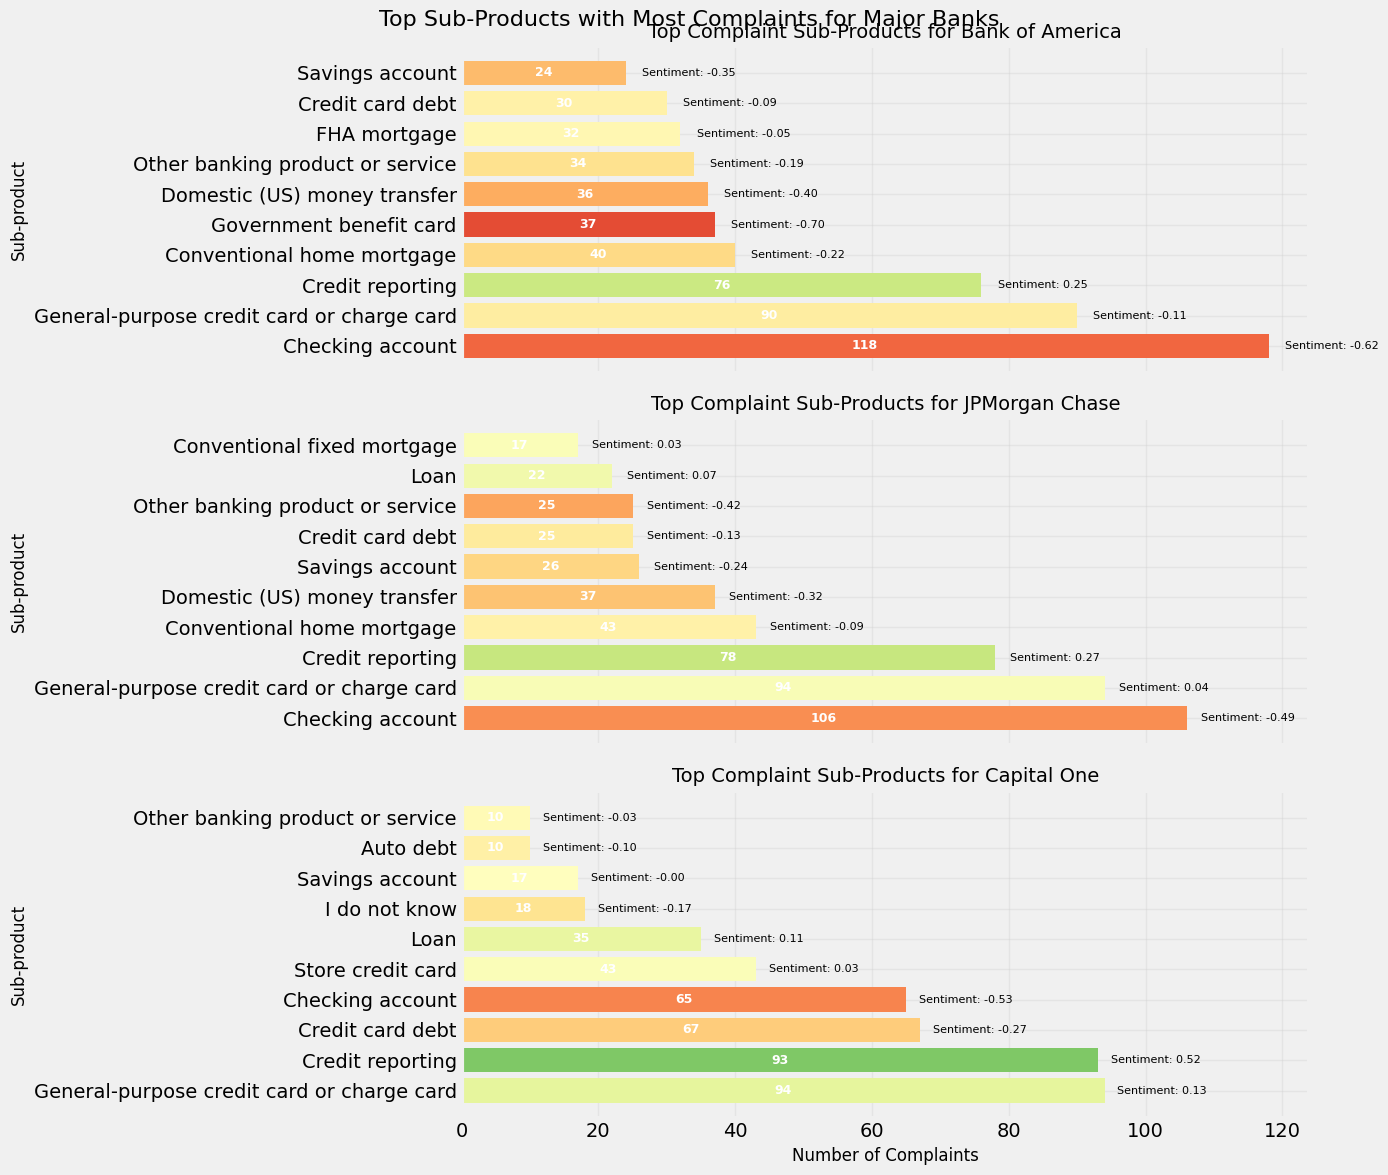

In [42]:
print("\n--- ANALYSIS 6: LOOK AT SUB-PRODUCTS FOR MAJOR BANKS ---")

major_banks = ['Bank of America', 'JPMorgan Chase', 'Capital One']
print(f"Analyzing top complaint sub-products for: {', '.join(major_banks)}")
fig, axes = plt.subplots(len(major_banks), 1, figsize=(14, 4*len(major_banks)), sharex=True)
for i, bank in enumerate(major_banks):
    bank_df = corpus_df[corpus_df['Company'].str.contains(bank, case=False, na=False)]
    
    if len(bank_df) == 0:
        axes[i].text(0.5, 0.5, f'No data found for {bank}', 
                    horizontalalignment='center', verticalalignment='center',
                    transform=axes[i].transAxes)
        continue
           
    subproduct_counts = bank_df.groupby('Sub-product')['Corpus'].count().reset_index()
    subproduct_counts = subproduct_counts.sort_values('Corpus', ascending=False).head(10)
    subproduct_counts.columns = ['Sub-product', 'Count']
    subproduct_sentiment = bank_df.groupby('Sub-product')['sentiment'].mean().reset_index()
    subproduct_analysis = pd.merge(subproduct_counts, subproduct_sentiment, on='Sub-product')
    ax = axes[i]
    bars = ax.barh(subproduct_analysis['Sub-product'], subproduct_analysis['Count'], 
             color=[plt.cm.RdYlGn(0.5 * (s + 1)) for s in subproduct_analysis['sentiment']])
    for j, (_, row) in enumerate(subproduct_analysis.iterrows()):
        ax.text(row['Count'] + (max(subproduct_analysis['Count']) * 0.02), 
                j, 
                f"Sentiment: {row['sentiment']:.2f}", 
                va='center',
                fontsize=8)
    for j, bar in enumerate(bars):
        ax.text(bar.get_width() / 2, 
                j,
                str(int(bar.get_width())),
                ha='center', 
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold')
    
    ax.set_title(f'Top Complaint Sub-Products for {bank}', fontsize=14)
    if i == len(major_banks) - 1:  # Only add x-label to the last subplot
        ax.set_xlabel('Number of Complaints', fontsize=12)
    ax.set_ylabel('Sub-product', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle('Top Sub-Products with Most Complaints for Major Banks', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Make room for the suptitle
plt.show()
plt.savefig('major_banks_subproduct_complaints.png', dpi=300, bbox_inches='tight')
plt.close()


**There are 117 complaints mentioning Bitcoin or cryptocurrency. COINBASE seems to be on the top.**

In [43]:

print("\n--- ANALYSIS 7: LET'S SEE HOW DATA SHOWS BITCOIN-RELATED COMPLAINTS ---")
# Search for Bitcoin-related terms in the corpus
bitcoin_keywords = ['bitcoin', 'btc', 'cryptocurrency', 'crypto']
bitcoin_mentions = corpus_df[corpus_df['Corpus'].str.lower().str.contains('|'.join(bitcoin_keywords), na=False)]
print(f"There are {len(bitcoin_mentions)} complaints mentioning Bitcoin or cryptocurrency")
if len(bitcoin_mentions) > 0:
    # Analyze which companies have Bitcoin complaints
    bitcoin_by_company = bitcoin_mentions.groupby('Company')['Corpus'].count().reset_index()
    bitcoin_by_company = bitcoin_by_company.sort_values('Corpus', ascending=False)
    bitcoin_by_company.columns = ['Company', 'Bitcoin Complaint Count']
    print("\nCompanies with Bitcoin-related complaints:")
    print(bitcoin_by_company.head(10).to_string(index=False))
    # Analyze sentiment of Bitcoin complaints
    bitcoin_mentions['sentiment'] = bitcoin_mentions['Corpus'].apply(
        lambda x: sia.polarity_scores(str(x))['compound'] if isinstance(x, str) else 0
    )
    avg_bitcoin_sentiment = bitcoin_mentions['sentiment'].mean()
    print(f"\nAverage sentiment of Bitcoin-related complaints: {avg_bitcoin_sentiment:.4f}")
    # Compare with overall average sentiment
    overall_sentiment = corpus_df['sentiment'].mean()
    print(f"Overall average sentiment of all complaints: {overall_sentiment:.4f}")
else:
    print("No Bitcoin-related complaints found in the dataset.")


--- ANALYSIS 7: LET'S SEE HOW DATA SHOWS BITCOIN-RELATED COMPLAINTS ---
There are 117 complaints mentioning Bitcoin or cryptocurrency

Companies with Bitcoin-related complaints:
                              Company  Bitcoin Complaint Count
                       Coinbase, Inc.                       43
                          Block, Inc.                        9
                      Foris DAX, Inc.                        9
                WELLS FARGO & COMPANY                        9
              Winklevoss Exchange LLC                        6
                 Paypal Holdings, Inc                        5
BANK OF AMERICA, NATIONAL ASSOCIATION                        4
      BAM Management US Holdings Inc.                        4
                 JPMORGAN CHASE & CO.                        3
               ROBINHOOD MARKETS INC.                        3

Average sentiment of Bitcoin-related complaints: -0.1928
Overall average sentiment of all complaints: -0.0886


**While Bitcoin complaints have started to get higher, the volume is still relatively low since not a lot of people own bitcoints.**


--- ANALYSIS 7B: BITCOIN COMPLAINTS BY YEAR ---
Years with Bitcoin complaints: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Bitcoin complaints trend by year:
 Year  Complaint_Count  Avg_Sentiment
 2016                1       0.993800
 2017                7      -0.276357
 2018                9       0.054933
 2019                4      -0.634275
 2020                3       0.746267
 2021               23       0.029922
 2022               20      -0.153150
 2023               19      -0.129500
 2024               21      -0.467795
 2025               10      -0.714990


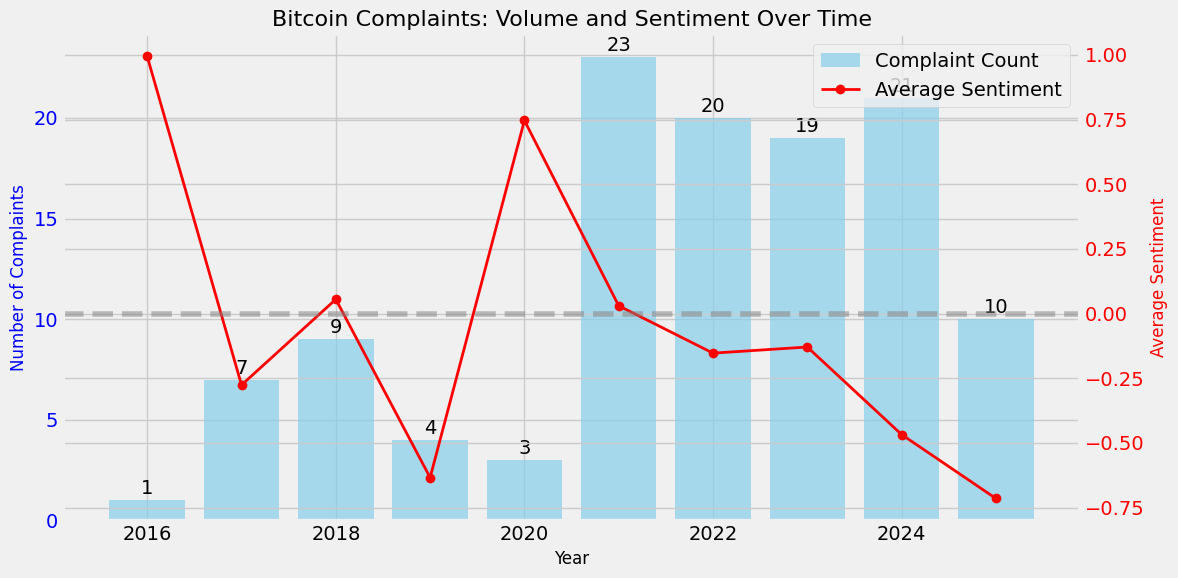

In [44]:
print("\n--- ANALYSIS 7B: BITCOIN COMPLAINTS BY YEAR ---")
if 'Year' not in bitcoin_mentions.columns:
    # Extract year from the Month datetime column
    bitcoin_mentions['Year'] = bitcoin_mentions['Month'].dt.year
years = sorted(bitcoin_mentions['Year'].unique())
print(f"Years with Bitcoin complaints: {years}")

bitcoin_by_year = bitcoin_mentions.groupby('Year').agg({
    'Corpus': 'count',
    'sentiment': 'mean'
}).reset_index()

bitcoin_by_year.columns = ['Year', 'Complaint_Count', 'Avg_Sentiment']
print("\nBitcoin complaints trend by year:")
print(bitcoin_by_year.to_string(index=False))
fig, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.bar(bitcoin_by_year['Year'], bitcoin_by_year['Complaint_Count'], 
       alpha=0.7, color='skyblue', label='Complaint Count')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Complaints', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
line = ax2.plot(bitcoin_by_year['Year'], bitcoin_by_year['Avg_Sentiment'], 
         'ro-', linewidth=2, label='Average Sentiment')
ax2.set_ylabel('Average Sentiment', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{int(height)}', ha='center', va='bottom')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='best')

plt.title('Bitcoin Complaints: Volume and Sentiment Over Time', fontsize=16)
plt.tight_layout()
plt.savefig('bitcoin_complaints_trend_by_year.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [45]:
print("\n--- ANALYSIS 9: How can we classify complaints---")

# Import necessary libraries for text classification
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

try:
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('omw-1.4') 

print("Preparing data for text classification...")
classification_df = corpus_df.copy()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    processed_text = ' '.join(tokens)
    return processed_text

classification_df['processed_text'] = classification_df['Corpus'].apply(preprocess_text)



--- ANALYSIS 9: How can we classify complaints---
Preparing data for text classification...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Banu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Banu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Banu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


**When we think about  classification model, we can use how severe the complaints are based on sentiment score, how urgent they are by defining what it means to be urgent, and clasify based on topics as well**

In [46]:
#Let's do classification based on sentiment
classification_df['severity'] = pd.cut(
    classification_df['sentiment'],
    bins=[-1.0, -0.5, -0.2, 0.2, 1.0],
    labels=['High', 'Medium', 'Low', 'Positive']
)

# Create topic classification based on keywords
def classify_topic(text):
    text = str(text).lower()
    if any(word in text for word in ['fee', 'charge', 'overcharge', 'billing', 'bill', 'cost']):
        return 'My Charges'
    elif any(word in text for word in ['fraud', 'scam', 'unauthorized', 'stolen', 'identity theft']):
        return 'Fraudulant activity'
    elif any(word in text for word in ['payment', 'transaction', 'transfer', 'deposit', 'withdrawal']):
        return 'Bank Transactions'
    elif any(word in text for word in ['account', 'close', 'open', 'freeze', 'locked']):
        return 'Account administration'
    elif any(word in text for word in ['loan', 'mortgage', 'credit', 'debt', 'interest', 'apr']):
        return 'Loans related'
    elif any(word in text for word in ['service', 'customer', 'representative', 'support', 'call']):
        return 'Customer related'
    else:
        return 'Other'

classification_df['topic'] = classification_df['Corpus'].apply(classify_topic)



In [47]:
# 2.3 Check and create flag for urgent wording
def flag_urgent(text, sentiment):
    text = str(text).lower()
    urgent_keywords = ['immediate', 'urgent', 'emergency', 'asap', 'quickly', 
                      'right away', 'critical', 'serious', 'now', 'desperate','confused','upset','frustrated',
                      'fed up','dissatisfied','annoyed','ridiculous','ludicrous','unbelievable','disgraceful',
                      'oh my god','you must be joking']
    
    # Flag as urgent if sentiment is very negative or urgent keywords are present
    if sentiment < -0.7 or any(word in text for word in urgent_keywords):
        return 1  # if Urgent
    return 0  # Not urgent

classification_df['urgent'] = classification_df.apply(
    lambda x: flag_urgent(x['Corpus'], x['sentiment']), axis=1
)



severity
High        10229
Positive     9862
Low          2566
Medium       2288
Name: count, dtype: int64
topic
My Charges                10623
Bank Transactions          4171
Fraudulant activity        3476
Account administration     3132
Loans related              2662
Other                       551
Customer related            350
Name: count, dtype: int64
urgent
1    16388
0     8577
Name: count, dtype: int64


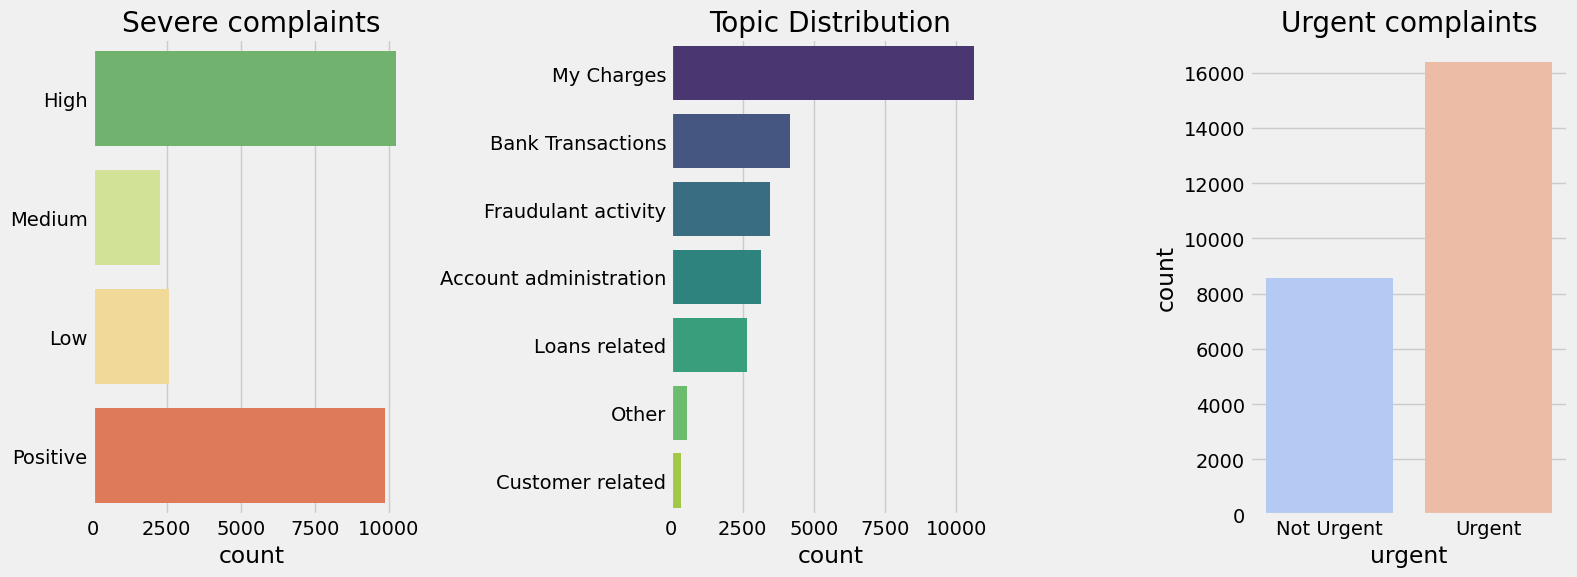

In [48]:

severity_counts = classification_df['severity'].value_counts()
print(severity_counts)
topic_counts = classification_df['topic'].value_counts()
print(topic_counts)
print(classification_df['urgent'].value_counts(dropna=False))
plt.figure(figsize=(16, 6))

plt.subplot(131)
sns.countplot(y=classification_df['severity'], palette='RdYlGn_r')
plt.title('Severe complaints')
plt.ylabel('')
plt.tight_layout()
 
plt.subplot(132)
topic_order = topic_counts.index
sns.countplot(y=classification_df['topic'], order=topic_order, palette='viridis')
plt.title('Topic Distribution')
plt.ylabel('')
plt.tight_layout()

plt.subplot(133)
sns.countplot(x=classification_df['urgent'].map({0: 'Not Urgent', 1: 'Urgent'}), palette='coolwarm')
plt.title('Urgent complaints')
plt.tight_layout()

plt.savefig('complaint_classification_targets.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()



In [49]:
# 5. Use SMOTE for correct balance

processed_text = classification_df['processed_text']
severity_target = classification_df['severity']
topic_target = classification_df['topic'] 
urgency_target = classification_df['urgent']
valid_indices = (~processed_text.isna()) & (~severity_target.isna()) & (~topic_target.isna()) & (~urgency_target.isna())
X_clean = processed_text[valid_indices]
y_severity = severity_target[valid_indices]
y_topic = topic_target[valid_indices]
y_urgency = urgency_target[valid_indices]

X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(X_clean, y_severity, test_size=0.2, random_state=42)
severity_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=2)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

severity_pipeline.fit(X_train_sev, y_train_sev)
y_pred = severity_pipeline.predict(X_test_sev)
print("\nSeverity Classification Report:")
print(classification_report(y_test_sev, y_pred))
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_sev, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=severity_pipeline.classes_, 
            yticklabels=severity_pipeline.classes_)
plt.title('Severity Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('severity_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()




Severity Classification Report:
              precision    recall  f1-score   support

        High       0.62      0.82      0.70      1983
         Low       0.65      0.19      0.30       534
      Medium       0.71      0.05      0.09       439
    Positive       0.69      0.74      0.72      2033

    accuracy                           0.65      4989
   macro avg       0.67      0.45      0.45      4989
weighted avg       0.66      0.65      0.61      4989



In [50]:
#Topic Classification Model 
X_train_topic, X_test_topic, y_train_topic, y_test_topic = train_test_split(X_clean, y_topic, test_size=0.2, random_state=42)
topic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
topic_pipeline.fit(X_train_topic, y_train_topic)
y_pred = topic_pipeline.predict(X_test_topic)
print("\nTopic Classification Report:")
print(classification_report(y_test_topic, y_pred))




Topic Classification Report:
                        precision    recall  f1-score   support

Account administration       0.75      0.75      0.75       587
     Bank Transactions       0.79      0.75      0.77       806
      Customer related       0.55      0.18      0.27        66
   Fraudulant activity       0.87      0.65      0.74       700
         Loans related       0.67      0.86      0.75       562
            My Charges       0.86      0.92      0.89      2165
                 Other       0.74      0.25      0.38       103

              accuracy                           0.81      4989
             macro avg       0.75      0.62      0.65      4989
          weighted avg       0.81      0.81      0.80      4989



In [51]:
# Urgency Classification Model
X_train_urg, X_test_urg, y_train_urg, y_test_urg = train_test_split(X_clean, y_urgency, test_size=0.2, random_state=42)
try:
    # Convert text to TF-IDF features first
    tfidf = TfidfVectorizer(max_features=3000)
    X_train_tfidf = tfidf.fit_transform(X_train_urg)
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train_urg)
    # Train model on resampled data
    print("Training urgency classification model...")
    urgency_model = RandomForestClassifier(n_estimators=100, random_state=42)
    urgency_model.fit(X_train_resampled, y_train_resampled)
    X_test_tfidf = tfidf.transform(X_test_urg)
    y_pred = urgency_model.predict(X_test_tfidf)
    print("\nUrgency Classification Report:")
    print(classification_report(y_test_urg, y_pred))
    if hasattr(urgency_model, "feature_importances_"):
        feature_importance = urgency_model.feature_importances_
        feature_names = tfidf.get_feature_names_out()
        
        # Create DataFrame of top features
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        })
        
        # Plot top 20 features
        plt.figure(figsize=(12, 8))
        top_features = importance_df.sort_values('importance', ascending=False).head(20)
        sns.barplot(x='importance', y='feature', data=top_features)
        plt.title('Top 20 Features for Predicting Urgent Complaints')
        plt.tight_layout()
        plt.savefig('urgency_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.close()
        
except Exception as e:
    print(f"Error in SMOTE processing: {e}")
    print("Continuing with conventional model training...")
    urgency_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000)),
        ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ])
    
    urgency_pipeline.fit(X_train_urg, y_train_urg)
    y_pred = urgency_pipeline.predict(X_test_urg)
    print("\nUrgency Classification Report (without SMOTE):")
    print(classification_report(y_test_urg, y_pred))

Training urgency classification model...

Urgency Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      1745
           1       0.86      0.88      0.87      3244

    accuracy                           0.82      4989
   macro avg       0.81      0.80      0.81      4989
weighted avg       0.82      0.82      0.82      4989



**WORD BIGRAM ANALYSIS:** In this section we can analyze word bigrams to see the 2 phrase combinations in the complaints database. About 137 words represent 50% of all word occurances. Some of them are "xxxx, credit, account, report, information, consumer, reporting, accounts, payment, debt, 
section, would, also, agency, please, inaccurate, bank, act, company, number, 
card, never, received, date, balance, days, late, time, dispute, loan"

In [52]:

from collections import Counter
from nltk.util import ngrams
corpus_df['complaint_id'] = corpus_df.index + 1
all_words = []
word_by_complaint = []
def extract_words(text, min_word_length=3):
    if not isinstance(text, str):
        return []
    tokens = nltk.word_tokenize(text.lower())
    stop_words = set(nltk.corpus.stopwords.words('english'))
    words = [word for word in tokens 
             if word.isalpha() and  
             len(word) >= min_word_length and  
             word not in stop_words]  
    return words
for idx, row in corpus_df.iterrows():
    words = extract_words(row['Corpus'])
    all_words.extend(words)
    # Store words with their complaint ID
    for word in words:
        word_by_complaint.append({
            'complaint_id': row['complaint_id'],
            'Company': row['Company'],
            'Sub-product': row['Sub-product'],
            'word': word
        })

word_df = pd.DataFrame(word_by_complaint)
print(f"Extracted {len(all_words)} total words from all complaints")
print(f"Found {len(set(all_words))} unique words")
word_counts = Counter(all_words)
word_freq_df = pd.DataFrame(word_counts.most_common(), columns=['word', 'count'])


Extracted 7668085 total words from all complaints
Found 37604 unique words


**Find common bigrams (2-word phrases). Its good to look at common phrases within this vocabulary.**


Top 20 most common two-word combination
                phrase   count
0            xxxx xxxx  760242
1        credit report   54284
2     credit reporting   25102
3         xxxx account   22085
4   consumer reporting   20699
5     reporting agency   19598
6          fair credit   16758
7       identity theft   16562
8        reporting act   15968
9        xxxx xxxxxxxx   13189
10        account xxxx   12631
11         number xxxx   12184
12       xxxxxxxx xxxx   11846
13      credit bureaus   11691
14     consumer report   11272
15      account number   11160
16         credit card   10566
17           name xxxx   10189
18      section states    8829
19     states consumer    8654


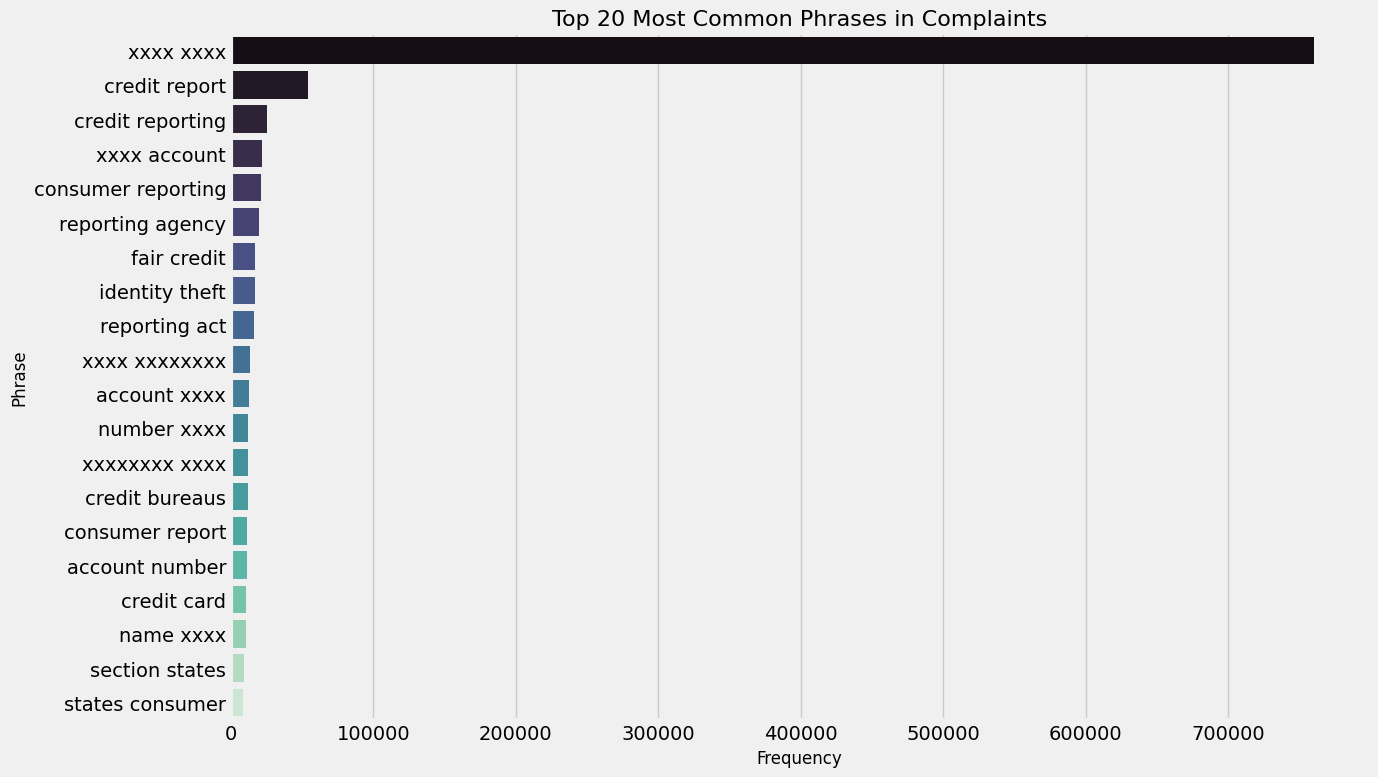

In [53]:

all_bigrams = []
for idx, row in corpus_df.iterrows():
    words = extract_words(row['Corpus'])
    bi_grams = list(ngrams(words, 2))
    bi_grams = [f"{w1} {w2}" for w1, w2 in bi_grams]
    all_bigrams.extend(bi_grams)
bigram_counts = Counter(all_bigrams)
bigram_df = pd.DataFrame(bigram_counts.most_common(20), columns=['phrase', 'count'])
print("\nTop 20 most common two-word combination")
print(bigram_df)
plt.figure(figsize=(14, 8))
sns.barplot(x='count', y='phrase', data=bigram_df, palette='mako')
plt.title('Top 20 Most Common Phrases in Complaints', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Phrase', fontsize=12)
plt.tight_layout()
plt.savefig('top_phrases_in_complaints.png', dpi=300, bbox_inches='tight')
plt.show()

**The Zipf law** plot shows that there is a good downward slope that's approximately linear on the log-log scale, this show that dataset follows the law where in word frequency is inversely proportional to its rank. Also because these are complaints , there a predictability on the vocabulary which helps us with better topic modeling due to well defined words that dominate the financial domain vocabulary. 

xxxx, credit, account, report, information, consumer, reporting, accounts, payment, debt, 
section, would, also, agency, please, inaccurate, bank, act, company, number, 
card, never, received, date, balance, days, late, time, dispute, loan, 
request, payments, identity, without, fair, states, sent, told, name, items, 
due, letter, fcra, complaint, made, reported, theft, file, remove, called, 
xxxxxxxx, usc, fraudulent, following, financial, rights, provide, written, back, one, 
amount, money, collection, law, person, may, removed, bureaus, get, paid, 
address, proof, right, creditor, said, violation, pay, still, reports, inquiries, 
fraud, make, could, privacy, call, phone, provided, since, within, immediately, 
personal, investigation, code, federal, disputed, inquiry, furnish, listed, even, need, 
matter, mortgage, years, regarding, opened, original, violated, take, equifax, must, 
required, asked, issue, experian, accurate, business, requested, agencies, response, copy, 
legal, see,

<Figure size 1600x1000 with 0 Axes>

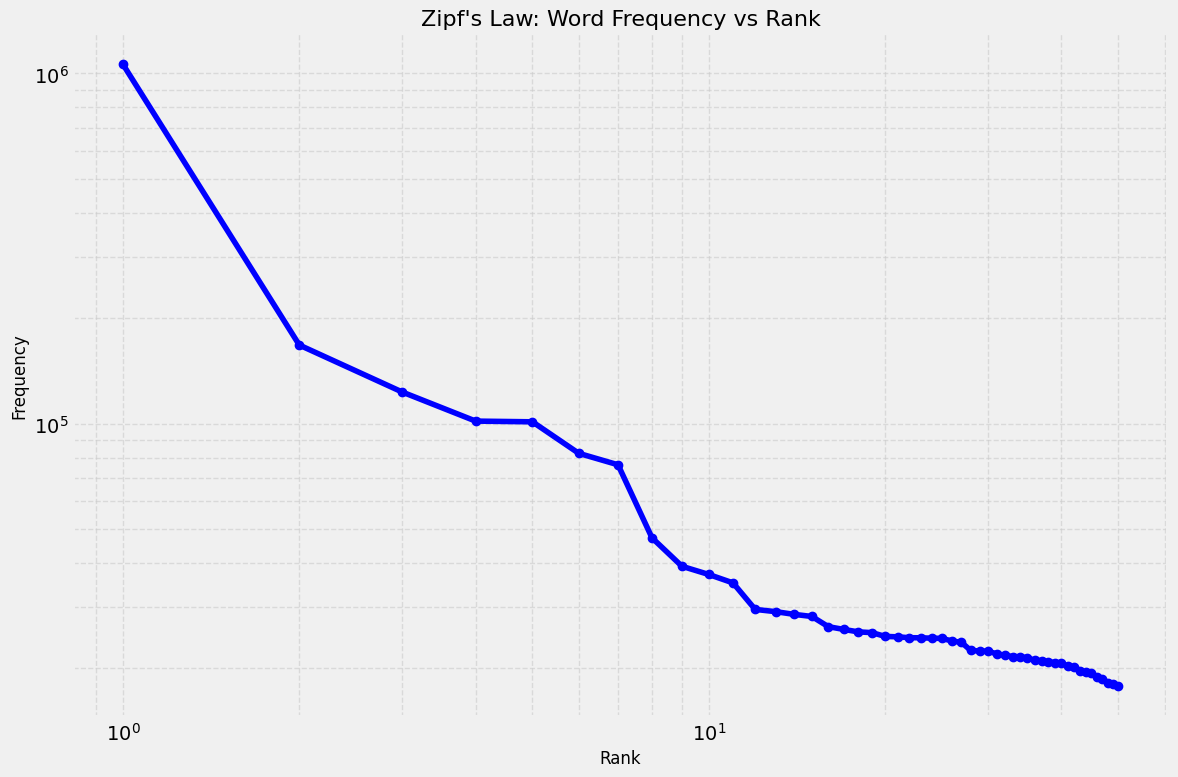

In [54]:

from collections import Counter

def top_half(word_counts):
    total_words = sum(word_counts.values())
    half_point = total_words / 2
    cumulative = 0
    word_count = 0
    
    for word, count in word_counts.most_common():
        cumulative += count
        word_count += 1
        if cumulative > half_point:
            return word_count

top_words_count = top_half(word_counts)
top_half_words = [word for word, count in word_counts.most_common(top_words_count)]
for i, word in enumerate(top_half_words):
    # Print in chunks of 10 words per line
    if i > 0 and i % 10 == 0:
        print()
    print(f"{word}", end=", " if i < len(top_half_words)-1 else "\n")
unique_words = len(set(all_words))
percentage = (top_words_count / unique_words) * 100
print(f"\nThese {top_words_count} words represent only {percentage:.2f}% of the vocabulary")
print(f"but make up 50% of all word occurrences in the complaints")
plt.figure(figsize=(16, 10))
words = [word for word, count in word_counts.most_common(50)]
counts = [count for word, count in word_counts.most_common(50)]
colors = ['darkred' if i < top_words_count else 'lightgray' for i in range(50)]

# Calculate Zipf's law metrics
ranks = range(1, len(words) + 1)
plt.figure(figsize=(12, 8))
plt.loglog(ranks, counts, 'bo-')
plt.title("Zipf's Law: Word Frequency vs Rank", fontsize=16)
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('zipf_law_complaints.png', dpi=300, bbox_inches='tight')
plt.show()